### Mounting Drive and Setting up Kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/deepfake_audio'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, 'checkpoints'), exist_ok=True)
print(f"Project dir: {PROJECT_DIR}" )

Mounted at /content/drive
Project dir: /content/drive/MyDrive/deepfake_audio


In [3]:
!pip install -q librosa==0.10.2 soundfile audiomentations==0.35.0 pydub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 22.9 MB/s eta 0:00:00


In [4]:
from google.colab import files
print("Upload your kaggle.json now:")
uploaded = files.upload()

Upload your kaggle.json now:


Saving kaggle.json to kaggle.json


In [5]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [6]:
import os
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset -p {DATA_DIR}

!unzip -q {DATA_DIR}/the-fake-or-real-dataset.zip -d {DATA_DIR}/for

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
100% 16.0G/16.0G [02:04<00:00, 138MB/s]



### Loading Dataset Paths

In [7]:
import pandas as pd

TRAIN_DIR = '/content/data/for/for-norm/for-norm/training'
REAL_DIR  = os.path.join(TRAIN_DIR, 'real')
FAKE_DIR  = os.path.join(TRAIN_DIR, 'fake')

def list_audio(folder, label):
    rows = []
    for f in os.listdir(folder):
        if f.lower().endswith(('.wav', '.flac', '.mp3')):
            rows.append({'path': os.path.join(folder, f), 'label': label})
    return rows

rows = list_audio(REAL_DIR, 'real') + list_audio(FAKE_DIR, 'fake')
df = pd.DataFrame(rows)

print("Total files:", len(df))
print(df['label'].value_counts())

Total files: 53868
label
real    26941
fake    26927
Name: count, dtype: int64


### EDA

In [8]:
import soundfile as sf
import numpy as np

def probe(path):
    try:
        info = sf.info(path)
        return info.frames / info.samplerate, info.samplerate, info.channels
    except Exception:
        return None, None, None

audit = df.groupby('label', group_keys=False).apply(
    lambda g: g.sample(min(len(g), 1500), random_state=0)
).copy()

durs, srs, chs = [], [], []

for p in audit['path']:
    d, s, c = probe(p)
    durs.append(d)
    srs.append(s)
    chs.append(c)

audit['duration'] = durs
audit['sr'] = srs
audit['channels'] = chs
audit = audit.dropna(subset=['duration'])

print("Sample rates by class:")
print(audit.groupby('label')['sr'].value_counts())
print("\nChannels by class:")
print(audit.groupby('label')['channels'].value_counts())

/tmp/ipykernel_1228/397494676.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  audit = df.groupby('label', group_keys=False).apply(


Sample rates by class:
label  sr   
fake   16000    1500
real   16000    1500
Name: count, dtype: int64

Channels by class:
label  channels
fake   1           1500
real   1           1500
Name: count, dtype: int64


In [9]:
print(audit.groupby('label')['duration'].describe()[['mean','std','min','25%','50%','75%','max']])

           mean       std       min       25%       50%       75%        max
label                                                                       
fake   1.691217  0.730945  0.332437  1.166250  1.564344  2.057969   5.361562
real   4.528169  2.353298  0.000000  2.757656  3.870875  6.115000  17.581375


In [10]:
import librosa

def silence_loudness(path, top_db=30):
    try:
        y, sr = librosa.load(path, sr=16000, mono=True)
        if len(y) == 0:
            return None, None, None
        rms = float(np.sqrt(np.mean(y**2)))
        # Compare trimmed length to original to estimate silence fraction.
        yt, _ = librosa.effects.trim(y, top_db=top_db)
        silence_frac = 1.0 - (len(yt) / len(y)) if len(y) > 0 else 0.0
        return rms, silence_frac, len(y)/sr
    except Exception:
        return None, None, None

# Smaller sample here since we fully decode (slower).
small = audit.groupby('label', group_keys=False).apply(
    lambda g: g.sample(min(len(g), 400), random_state=1)
).copy()

rmss, sils = [], []
for p in small['path']:
    r, s, _ = silence_loudness(p)
    rmss.append(r); sils.append(s)
small['rms'] = rmss
small['silence_frac'] = sils
small = small.dropna(subset=['rms'])

print("Loudness (RMS) by class:")
print(small.groupby('label')['rms'].describe()[['mean','std','50%']])
print("\nSilence fraction by class:")
print(small.groupby('label')['silence_frac'].describe()[['mean','std','50%']])

/tmp/ipykernel_1228/2343059407.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  small = audit.groupby('label', group_keys=False).apply(


Loudness (RMS) by class:
           mean       std       50%
label                              
fake   0.183163  0.040115  0.180752
real   0.150319  0.065663  0.138505

Silence fraction by class:
       mean  std  50%
label                
fake    0.0  0.0  0.0
real    0.0  0.0  0.0


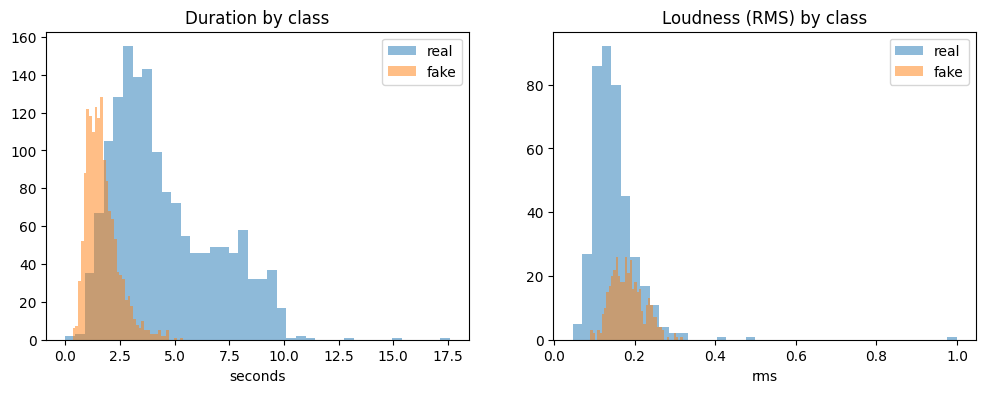

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lab in ['real', 'fake']:
    axes[0].hist(audit[audit.label==lab]['duration'], bins=40, alpha=0.5, label=lab)
    axes[1].hist(small[small.label==lab]['rms'], bins=40, alpha=0.5, label=lab)

axes[0].set_title('Duration by class')
axes[0].set_xlabel('seconds')
axes[0].legend()

axes[1].set_title('Loudness (RMS) by class')
axes[1].set_xlabel('rms')
axes[1].legend()

plt.show()